In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("DATA FOR STUDENT PREDICTION.csv")
print(df)

     StudentID  Gender  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
0            1    Male              85                 15             78   
1            2  Female              90                 20             85   
2            3    Male              78                 10             65   
3            4    Male              92                 25             90   
4            5  Female              88                 18             82   
..         ...     ...             ...                ...            ...   
995        996    Male              85                 20             78   
996        997  Female              91                 18             86   
997        998    Male              85                  8             82   
998        999    Male              88                 17             60   
999       1000  Female              88                 10             90   

     ExtracurricularActivities ParentalSupport  FinalGrade  StudyHours  \
0            

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1000 non-null   int64  
 1   Gender                     1000 non-null   object 
 2   AttendanceRate             1000 non-null   int64  
 3   StudyHoursPerWeek          1000 non-null   int64  
 4   PreviousGrade              1000 non-null   int64  
 5   ExtracurricularActivities  1000 non-null   int64  
 6   ParentalSupport            1000 non-null   object 
 7   FinalGrade                 1000 non-null   int64  
 8   StudyHours                 1000 non-null   float64
 9   AttendancePercent          1000 non-null   int64  
 10  Online Classes Taken       1000 non-null   bool   
dtypes: bool(1), float64(1), int64(7), object(2)
memory usage: 79.2+ KB


In [4]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,StudyHours,AttendancePercent
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,85.610000,17.649000,77.612000,1.498000,80.029000,2.409200,77.197000
std,288.819436,7.200399,6.113688,9.840238,1.029104,9.301649,1.600749,18.899613
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,250.750000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,64.000000
50%,500.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,750.250000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,1000.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [5]:
df.isnull().sum()

StudentID                    0
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
StudyHours                   0
AttendancePercent            0
Online Classes Taken         0
dtype: int64

<Axes: xlabel='FinalGrade', ylabel='Count'>

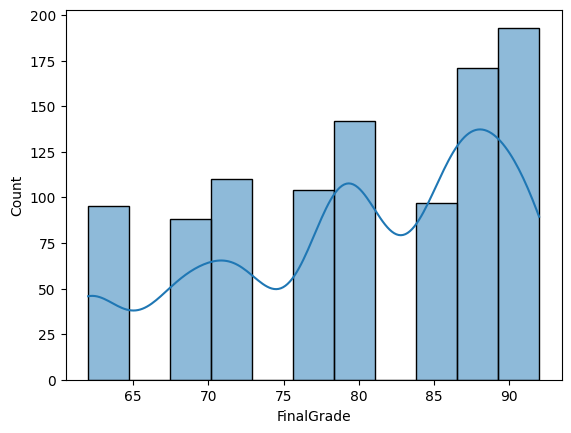

In [6]:
sns.histplot(df['FinalGrade'], kde=True)

<Axes: xlabel='Gender', ylabel='count'>

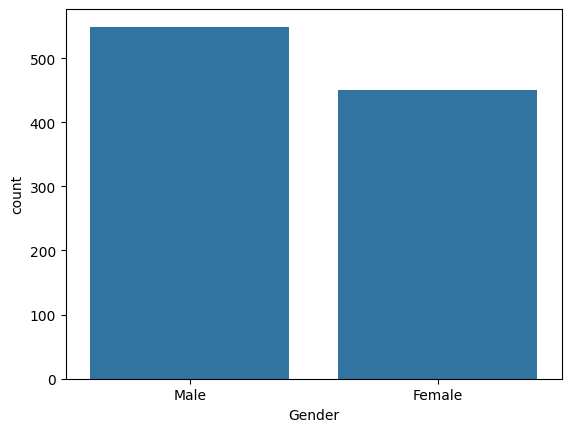

In [7]:
sns.countplot(x='Gender', data=df)

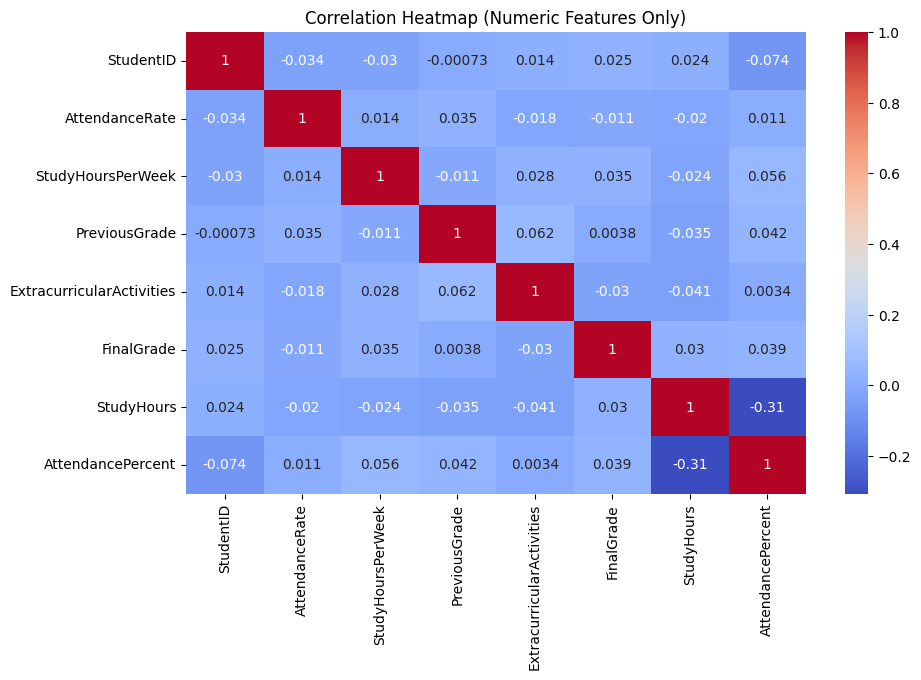

In [8]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [9]:
df_clean = df.copy()   # work on a clean copy

# 2.1 Remove columns that don't help the model
df_clean = df_clean.drop(columns=['StudentID'])

In [10]:
#Label Encode categorical columns
label_cols = ['Gender', 'ExtracurricularActivities', 
              'ParentalSupport', 'Online Classes Taken']

label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le   # store encoders for future predictions

print("Data cleaning complete ✔️")
display(df_clean.head())

Data cleaning complete ✔️


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,StudyHours,AttendancePercent,Online Classes Taken
0,1,85,15,78,1,0,80,4.8,59,0
1,0,90,20,85,2,2,87,2.2,70,1
2,1,78,10,65,0,1,68,4.6,92,0
3,1,92,25,90,3,0,92,2.9,96,0
4,0,88,18,82,2,2,85,4.1,97,1


In [11]:
# STEP 3 — Create dropout column in the original df

df['Dropout'] = (
    (df['AttendanceRate'] < 70) | 
    (df['FinalGrade'] < 40) |
    ((df['StudyHoursPerWeek'] < 10) & (df['PreviousGrade'] < 60)) |
    ((df['ParentalSupport'] == 'Low') & (df['AttendanceRate'] < 75))
).astype(int)

print("Dropout column created ✔️")


Dropout column created ✔️


In [12]:
# Make a copy for cleaning
df_clean = df.copy()

from sklearn.preprocessing import LabelEncoder

# Columns to encode
label_cols = ['Gender', 'ExtracurricularActivities', 
              'ParentalSupport', 'Online Classes Taken']

label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le   # store encoders for future predictions

print("Encoding complete ✔️")
df_clean.head()

Encoding complete ✔️


,StudentID,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,StudyHours,AttendancePercent,Online Classes Taken,Dropout
0,1,1,85,15,78,1,0,80,4.8,59,0,0
1,2,0,90,20,85,2,2,87,2.2,70,1,0
2,3,1,78,10,65,0,1,68,4.6,92,0,0
3,4,1,92,25,90,3,0,92,2.9,96,0,0
4,5,0,88,18,82,2,2,85,4.1,97,1,0


In [13]:
# Cell 5: preprocessing (FINAL)

df_clean = df.copy()

# ❌ REMOVE StudentID BEFORE ANY TRAINING
df_clean = df_clean.drop(columns=['StudentID'])

# Encode categorical columns
label_cols = ['Gender', 'ExtracurricularActivities', 'ParentalSupport', 'Online Classes Taken']
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print("StudentID removed ✔️")

df_clean.head()


StudentID removed ✔️


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,StudyHours,AttendancePercent,Online Classes Taken,Dropout
0,1,85,15,78,1,0,80,4.8,59,0,0
1,0,90,20,85,2,2,87,2.2,70,1,0
2,1,78,10,65,0,1,68,4.6,92,0,0
3,1,92,25,90,3,0,92,2.9,96,0,0
4,0,88,18,82,2,2,85,4.1,97,1,0


In [14]:
# ===============================
# RANDOM FOREST + GRIDSEARCH (Replace old train/split cells with this)
# ===============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE

# Cell 6: train-test split + scaling (CORRECT)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features & target
leakage_cols = [
    'FinalGrade',
    'AttendanceRate',
    'StudyHoursPerWeek'
]

X = df_clean.drop(['Dropout'] + leakage_cols, axis=1)
y = df_clean['Dropout']


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to training data ONLY

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Train Random Forest (NO SCALING NEEDED)
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced", 
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_resampled, y_train_resampled)

print("Model training complete ✔️")



Model training complete ✔️


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC:", roc_auc_score(y_test, y_prob))



Confusion Matrix:
[[182  10]
 [  5   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       192
           1       0.23      0.38      0.29         8

    accuracy                           0.93       200
   macro avg       0.60      0.66      0.62       200
weighted avg       0.94      0.93      0.93       200


ROC AUC: 0.8385416666666666


In [16]:
# Cell 8: Save model and encoders (NO scaler for Random Forest)
artifact = {
    'model': best_rf,
    'label_encoders': label_encoders
}

joblib.dump(artifact, 'student_dropout_rf_best.pkl')
print("Saved: student_dropout_rf_best.pkl")


Saved: student_dropout_rf_best.pkl


In [17]:
import pandas as pd
import joblib

# Load saved model artifact
artifact = joblib.load("student_dropout_rf_best.pkl")
model = artifact["model"]
label_encoders = artifact["label_encoders"]

# Sample student (HIGH RISK example)
sample = {
    "Gender": "Male",
    "PreviousGrade": 35,
    "ExtracurricularActivities": "0",
    "ParentalSupport": "Low",
    "Online Classes Taken": "False",
    "StudyHours": 2.0,
    "AttendancePercent": 50
}


# Convert to DataFrame
df_sample = pd.DataFrame([sample])

# Encode categorical columns
for col, le in label_encoders.items():
    df_sample[col] = le.transform(df_sample[col].astype(str))

# Ensure same feature order used in training
df_sample = df_sample[model.feature_names_in_]

# Predict probability
probability = model.predict_proba(df_sample)[0][1] * 100

# Apply threshold
decision = "Yes" if probability >= 50 else "No"

# 🔥 PRINT RESULTS (THIS WAS MISSING)
print("Dropout Prediction:", decision)
print(f"Dropout Probability: {probability:.2f}%")

# Optional: display the input table
df_sample


Dropout Prediction: No
Dropout Probability: 13.16%


,Gender,PreviousGrade,ExtracurricularActivities,ParentalSupport,StudyHours,AttendancePercent,Online Classes Taken
0,1,35,0,1,2.0,50,0


In [18]:
Cell 10: Model Deployment (Flask API & Streamlit App)

After training and validating the Random Forest model, the trained model is exported as a .pkl file using joblib.

This file contains:

The trained Random Forest model

The fitted StandardScaler

The fitted LabelEncoder objects

These artifacts allow the model to be reused outside the notebook without retraining.

Deployment Architecture

Flask (Backend API)

Handles incoming student data as JSON

Applies the same preprocessing (encoding + scaling)

Returns dropout probability and Yes/No classification

Streamlit (Frontend UI)

Provides a graphical interface for users

Collects student information using forms

Sends the data to the model and displays predictions

This separation allows the machine learning model to be used in:

Web applications

Dashboards

Mobile apps

Institutional systems

The notebook is only responsible for training and exporting the model.

SyntaxError: invalid syntax (2054853046.py, line 1)